# Cálculo del target
## 1. Intro: Calcular morosidad desde pagos

**Autor:** Federico Moreno

Esta notebook construye la variable de target.

En las empresas de créditos el problema principal suele ser cómo otorgar correctamente el crédito a personas que tengan posibilidad de pago y voluntad de pago. 

Posibilidad de pago tiene aristas tales como el capacidad de pagar la misma cuota que da la empresa. Tambien es importante muchas veces entender no solo la probabilidad de pago en sí, sino la liquidez del cliente y cómo queda proporcional esa cuota al ingreso declarado o inferido. 

Para armar una política de otorgar creditos, muchas empresas se basan en: 
* Scorecards propios, que pueden ser basado en data adquirida pro la solicutd o data adquirida externamente a la aportada por el solicitante, en donde suman o restan segun rangos de variables
* Modelos de bureaus de c´reditos, como TransUnion, Equifax, Veraz o Nosis, que agregan historial crediticio de instutciones mas formales o informales y devuelven un score
* Modelos entrenados sobre la propia mora

Esta última es la que más nos interesa dado que vamso aintentar construir un modelo que prédiga correctamente una probabilidad de mora.

por lo tanto la pregunta es ¿Cómo se calcula la mora? 

Para eso mostraremos cómo a partir del dataset de pagos (o ausencia de estos) se peude construir la definicion del target.  Muchas veces no existe un falg tan claro cómo pagó o no pagó, sino que lo que existe es cierto historial de cuotas con dias de atrasos. 

Es importante entender que si este calculo esta equivocado, la solevencia de la empresa puede estar en riesgo. Muchas empresas en vez de tomar este número cómo algo continuo lo toman de manera discreta. Es decir, a cierre de mes se observa cuantos créditos se entregaron y se va a siguiendo la morosidad de ese emes entregado. Este error, que observé más veces de las que puedo admitir, es sumamente importante. 

Llamemosle a la fecha de entrega T. Una política que he observado es que muchos créditos que se dan en los primeros días del mes vencen en el momento t+1 es decir, su primer pago debe ser en ese mismo mes, en cambio otros créditos que se desembolsan los ultimos dias del mes se suele poner una fecha de pago en t+2. Si a esto le agregamos que muchas veces existe la política de te bonificamos la primer cuota, lleva a generar gran ocultamiento de lo que es la mora.

Supongamos que definimos como mora 3 meses desde la fecha que debía pagar la cuota. Si el crédito fue dado en los primeros dias del mes, los 3 meses se va a dar al mes 4 desde que el cliente se le desembolso el prestamo, pero si se le dio en los ultimos dias del mes correspondera al mes 5. El corte discreto oculta mora y no nos deja ver que el vencimiento llegó más tarde, aunque el corte continuo tampoco nos deja entender los dias que se transcurrieron respecto al desembolso sin pagar.

Por lo tanto importante a entender que en realidad elegir 90 dias de atraso, pueden ser en realidad los 90 dias desde la fecha que debia pagar y tambien peuden significar hasta 135 dias desde fue desembolsado su prestamo.


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from pathlib import Path
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

# Definir la ruta raíz (un nivel arriba de /notebooks)
project_path = Path.cwd().parent 

# Inicializar el proyecto
bootstrap_project(project_path)

# Crear la sesión y cargar el catálogo
with KedroSession.create(project_path) as session:
    context = session.load_context()
    catalog = context.catalog

# Ahora puedes cargar tu dataset
pagos = catalog.load("pagos")


[03/04/26 22:32:19] INFO     Using                                                                  ]8;id=612906;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=228641;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro/framework/project/__init__.py#269\269]8;;\
                             '/Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk                
                             -frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro/framework                
                             /project/rich_logging.yml' as logging configuration.                                  

[03/04/26 22:32:19] WARNING  /Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk- ]8;id=958860;file:///Users/federicomoreno/.pyenv/versions/3.11.8/lib/python3.11/warnings.py\warnings.py]8;;\:]8;id=246453;file:///Users/federicomoreno/.pyenv/versions/3.11.8/lib/python3.11/warnings.py#110\110]8;;\
                             frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/requests/__init_                
                             _.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet                       
                             (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!                 
                               warnings.warn(                                                                      
                                                                                                                   

[03/04/26 22:32:20] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=309054;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=886778;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[03/04/26 22:32:21] INFO     Loading data from pagos (CSVDataset)...                           ]8;id=253014;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=503918;file:///Users/federicomoreno/Library/Caches/pypoetry/virtualenvs/credit-risk-frontier-CNrUt1_n-py3.11/lib/python3.11/site-packages/kedro/io/data_catalog.py#1048\1048]8;;\

In [3]:

pagos.shape

(42691, 15)

In [4]:
pagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42691 entries, 0 to 42690
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credito_id_anon   42691 non-null  object 
 1   cliente_id_anon   42691 non-null  object 
 2   fecha_desembolso  42691 non-null  object 
 3   numero_cuota      42691 non-null  int64  
 4   dias_retraso      42691 non-null  float64
 5   fecha_t_pago      42691 non-null  object 
 6   fecha_pago        16119 non-null  object 
 7   valor_pagado      42141 non-null  float64
 8   estatus_credito   42691 non-null  object 
 9   ciudad            42659 non-null  object 
 10  sexo              42691 non-null  object 
 11  tipo_de_negocio   15834 non-null  object 
 12  origen            42691 non-null  object 
 13  max_dias_retraso  42691 non-null  float64
 14  target            39912 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 4.9+ MB


In [32]:
pagos[['credito_id_anon', 'cliente_id_anon', 'fecha_desembolso',
       'numero_cuota', 'dias_retraso', 'fecha_t_pago', 'fecha_pago',
       'valor_pagado']]

,credito_id_anon,cliente_id_anon,fecha_desembolso,numero_cuota,dias_retraso,fecha_t_pago,fecha_pago,valor_pagado
0,59a55e5140d9,5b4b739391cd,2021-10-29,1,0.0,2021-11-27,2021-11-27,137000.0
1,59a55e5140d9,5b4b739391cd,2021-10-29,2,0.0,2021-12-27,2021-12-17,137000.0
2,59a55e5140d9,5b4b739391cd,2021-10-29,3,0.0,2022-01-26,2022-01-20,137000.0
3,59a55e5140d9,5b4b739391cd,2021-10-29,4,0.0,2022-02-25,2022-02-21,137000.0
4,59a55e5140d9,5b4b739391cd,2021-10-29,5,0.0,2022-03-27,2022-03-23,137000.0
...,...,...,...,...,...,...,...,...
42686,b82016ab6e98,5491cdcf0c67,2024-05-10,3,0.0,2024-08-20,NaN,0.0
42687,b82016ab6e98,5491cdcf0c67,2024-05-10,4,0.0,2024-09-20,NaN,0.0
42688,b82016ab6e98,5491cdcf0c67,2024-05-10,5,0.0,2024-10-20,NaN,0.0
42689,b82016ab6e98,5491cdcf0c67,2024-05-10,6,0.0,2024-11-20,NaN,0.0


In [6]:
(pagos.isna().sum()/len(pagos)).sort_values(ascending=False)


tipo_de_negocio     0.629102
fecha_pago          0.622426
target              0.065096
valor_pagado        0.012883
ciudad              0.000750
credito_id_anon     0.000000
cliente_id_anon     0.000000
fecha_desembolso    0.000000
numero_cuota        0.000000
dias_retraso        0.000000
fecha_t_pago        0.000000
estatus_credito     0.000000
sexo                0.000000
origen              0.000000
max_dias_retraso    0.000000
dtype: float64

In [7]:
pagos["fecha_t_pago"] = pd.to_datetime(pagos["fecha_t_pago"])
pagos["fecha_desembolso"] = pd.to_datetime(pagos["fecha_desembolso"])

In [8]:
pagos.fecha_t_pago.max()

Timestamp('2026-03-20 00:00:00')

## 2. El sego de la 1er Cuota

### Distribucion entre fecha de desemboslo y fecha de pago

La cantidad de dias entre la fecha teórica de pago y la fecha de desembolso determina la cantidad de dias que tiene el cliente para su primera obligacion 
 
 La `fecha_t_pago` es la fecha en que se debería pagar la primera cuota del prestamo.


In [9]:
primera = (
    pagos.sort_values("numero_cuota")
    .groupby("credito_id_anon", as_index=False)
    .first()
)

In [10]:

primera["dia_desembolso"]       = primera["fecha_desembolso"].dt.day
primera["mes_desembolso"]       = primera["fecha_desembolso"].dt.to_period("M")
primera["mes_t_pago"]           = primera["fecha_t_pago"].dt.to_period("M")
primera["delta_meses"]          = (primera["mes_t_pago"] - primera["mes_desembolso"]).apply(lambda x: x.n)
primera["dias_hasta_vencimiento"] = (primera["fecha_t_pago"] - primera["fecha_desembolso"]).dt.days



In [11]:
print(f"Créditos en primera cuota: {len(primera):,}")


Créditos en primera cuota: 10,428


In [12]:
primera[["dia_desembolso", "delta_meses", "dias_retraso", "target"]].describe()

,dia_desembolso,delta_meses,dias_retraso,target
count,10428.000000,10428.000000,10428.000000,9840.000000
mean,16.880035,1.360568,127.391926,0.537500
std,8.843453,0.560544,198.184258,0.498617
min,1.000000,-11.000000,0.000000,0.000000
25%,10.000000,1.000000,0.000000,0.000000
50%,17.000000,1.000000,6.000000,1.000000
75%,24.000000,2.000000,207.000000,1.000000
max,31.000000,5.000000,859.000000,1.000000


In [13]:
dias = primera["dias_hasta_vencimiento"]
print("── Distribución completa ──")
print(dias.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0))
print(f"\nNegativos (errores de fecha): {(dias < 0).sum()}")

── Distribución completa ──
count    10428.0
mean        37.0
std          9.0
min       -324.0
1%          16.0
5%          28.0
25%         33.0
50%         37.0
75%         41.0
95%         46.0
99%         70.0
max        161.0
Name: dias_hasta_vencimiento, dtype: float64

Negativos (errores de fecha): 5


In [14]:
# Rango válido (excluir 5 negativos y outliers >p99)
p99     = primera["dias_hasta_vencimiento"].quantile(0.99)
validos = primera[primera["dias_hasta_vencimiento"].between(0, p99)].copy()

print(f"Créditos totales: {len(primera):,}  |  En rango válido: {len(validos):,}")

Créditos totales: 10,428  |  En rango válido: 10,353


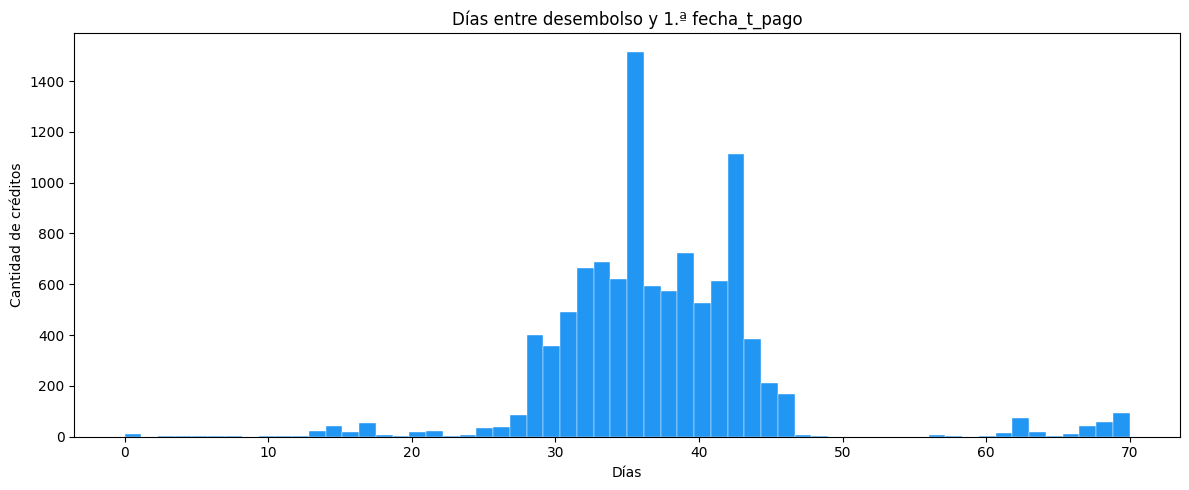

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(validos["dias_hasta_vencimiento"], bins=60,
        color="#2196F3", edgecolor="white", linewidth=0.3)
ax.set_title("Días entre desembolso y 1.ª fecha_t_pago")
ax.set_xlabel("Días")
ax.set_ylabel("Cantidad de créditos")
plt.tight_layout()
plt.show()

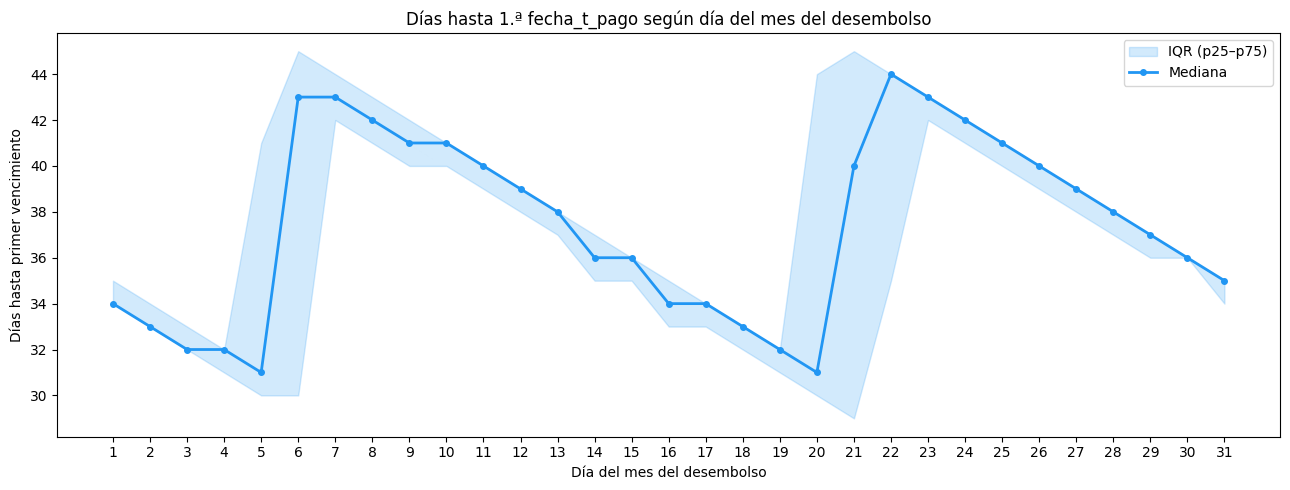

In [16]:
por_dia = (
    primera[primera["dias_hasta_vencimiento"].between(0, p99)]
    .groupby("dia_desembolso")["dias_hasta_vencimiento"]
    .agg(mediana="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), n="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(por_dia["dia_desembolso"], por_dia["q25"], por_dia["q75"],
                alpha=0.2, color="#2196F3", label="IQR (p25–p75)")
ax.plot(por_dia["dia_desembolso"], por_dia["mediana"],
        color="#2196F3", linewidth=2, marker="o", markersize=4, label="Mediana")
ax.set_title("Días hasta 1.ª fecha_t_pago según día del mes del desembolso")
ax.set_xlabel("Día del mes del desembolso")
ax.set_ylabel("Días hasta primer vencimiento")
ax.set_xticks(range(1, 32))
ax.legend()
plt.tight_layout()
plt.show()

En el gráfico anterior vemos lo que queriamos entender, la difernecia respecto a la fecha de desembolso respecto a la fecha del primer pago. 

Dos créditos dados en el mismo mes pueden tener de diferencia 15 días para pagar y no solo eso, si nosotros estamos viendo la morosidad del mes de enero y todos los prestamos se dieron en el dia 22, lo que vamos a recien ver el pago son 45 dias despues, es decir, a principios de marzo. Eso significa que si cortamos el análisis a fin de enero o incluso a fin de febrero,  ningún crédito de esa cohorte habrá llegado siquiera a su primer vencimiento 

                                                                                                                            
Si en cambio los créditos se dieron el día 5 de enero, el primer vencimiento cae alrededor del 9 de febrero — solo 35 días después. Al mismo corte de fin de febrero, estos créditos llevan ya casi 20 días desde su primer vencimiento y pueden empezar a mostrar retraso.                                                      


In [17]:
VENTANA_T3 = 90
por_dia["exposicion_T3"]  = VENTANA_T3 - por_dia["mediana"]
por_dia["exposicion_90d"] = 90  #

In [18]:
print("── ¿Puede observarse mora ≥ 90 días según tipo de corte? ──\n")
print("  Corte T+3 discreto (90 días desde desembolso):")
max_exp = por_dia["exposicion_T3"].max()
min_exp = por_dia["exposicion_T3"].min()
print(f"    Exposición máxima posible: {max_exp:.0f} días  → mora 90d NUNCA observable")
print(f"    Exposición mínima posible: {min_exp:.0f} días")
print(f"    Brecha máxima ocultada:    {90 - min_exp:.0f} días de mora potencial no visibles\n")
print("  Corte 90d continuo (desde fecha_t_pago):")
print("    Exposición: exactamente 90 días para cada crédito → mora 90d SÍ observable")

# Verificar en datos reales: tasa de >90d en primera cuota
n_gt90 = (validos["dias_retraso"] > 90).sum()
n_tot  = validos["dias_retraso"].notna().sum()
print(f"\n  En los datos reales: {n_gt90:,} de {n_tot:,} créditos ({100*n_gt90/n_tot:.1f}%)")
print("  tienen >90 días de retraso en la 1.ª cuota — pero solo son visibles")
print("  con un corte que respete los días reales desde el primer vencimiento.")


── ¿Puede observarse mora ≥ 90 días según tipo de corte? ──

  Corte T+3 discreto (90 días desde desembolso):
    Exposición máxima posible: 59 días  → mora 90d NUNCA observable
    Exposición mínima posible: 46 días
    Brecha máxima ocultada:    44 días de mora potencial no visibles

  Corte 90d continuo (desde fecha_t_pago):
    Exposición: exactamente 90 días para cada crédito → mora 90d SÍ observable

  En los datos reales: 3,191 de 10,353 créditos (30.8%)
  tienen >90 días de retraso en la 1.ª cuota — pero solo son visibles
  con un corte que respete los días reales desde el primer vencimiento.


## 3. Cálculo de la mora desde los datos

La mora entonces aparecerá en nustro dataset de entrenamiento como un flag, sabemos igual que lo que existen en nuestro dataset de apgos ess `dias_retraso` por cuota y esto representa la distancia en la `fecha_t_pago` teórica y el pago real hecho por el cliente.
Por eso para construir la mora se toma el máximo de dias de atraso y un cliente que era moroso un mes, más adelante puede regularizarse o viceversa, un cliente que un mes puede haber pagado bien puede luego estar atrasado. Un crédito es tan moroso como su cuota más atrasada.


Se pueden definir los umbrales de 
**Pagó** (`target = 1`): `max_dias_retraso ≤ 30`
**Default** (`target = 0`): `max_dias_retraso > 60`
**Zona gris** (excluido): `30 < max_dias_retraso ≤ 60` — mora ambigua

In [19]:
UMBRAL_PAGO    = 30
UMBRAL_DEFAULT = 60

def asignar_target(dias: float) -> float | None:
    if pd.isna(dias):
        return None
    if dias <= UMBRAL_PAGO:
        return 1.0
    if dias > UMBRAL_DEFAULT:
        return 0.0
    return None  # zona gris

In [20]:
mora_real = (
    pagos.groupby("credito_id_anon")["dias_retraso"]
    .max()
    .reset_index()
    .rename(columns={"dias_retraso": "max_mora_real"})
)
mora_real["target_real"] = mora_real["max_mora_real"].apply(asignar_target)


In [21]:

n_tot   = len(mora_real)
n_pago  = (mora_real["target_real"] == 1).sum()
n_def   = (mora_real["target_real"] == 0).sum()
n_gris  = mora_real["target_real"].isna().sum()

print("── Mora real (todas las cuotas, sin restricción temporal) ──")
print(f"  Pagó    (≤ {UMBRAL_PAGO}d):   {n_pago:>6,}  ({100*n_pago/n_tot:.1f}%)")
print(f"  Default (> {UMBRAL_DEFAULT}d):   {n_def:>6,}  ({100*n_def/n_tot:.1f}%)")
print(f"  Zona gris:       {n_gris:>6,}  ({100*n_gris/n_tot:.1f}%)")
print(f"  Total créditos:  {n_tot:>6,}")

── Mora real (todas las cuotas, sin restricción temporal) ──
  Pagó    (≤ 30d):    5,289  (50.7%)
  Default (> 60d):    4,551  (43.6%)
  Zona gris:          588  (5.6%)
  Total créditos:  10,428


Hasta acá mostramos la diferencia entre mirar discretamente o continuamente los dias de atrasos, tambien el entendimiento de la política de otorgamiento cómo muchas veces no se comunica correctamente con la política de cobros y el peligro de no ser entendido esto por la dirección financiera que debe tener en claro cual es la tasa de mora de la empresa

Pero hasta este momento podriamos decir que hay 5,289 que pagaron y 4,551 que no pagaron. Ahora bien ¿es cierto que todos los 5mil pagaron?

Para que un crédito pueda ser clasificado como buen pagador necesitamos haberle dado la oportunidad real de defaultear, es decir que haya pasado un tiempo posible para esto.

  `días_mínimos = dias_hasta_vencimiento + UMBRAL_DEFAULT`


 Un crédito que todavía no cumplió ese mínimo desde el desembolso **no puede ser ni "pagó" ni "default"** — simplemente no sabemos. Incluirlo como "pagó" le enseña al modelo que ese perfil es seguro, cuando en realidad es un crédito al que no le dimos tiempo suficiente de fallar.


In [22]:
FECHA_CORTE = pagos["fecha_desembolso"].max()
print(f"Fecha de corte del análisis: {FECHA_CORTE.date()}")

Fecha de corte del análisis: 2024-05-10


In [23]:
madurez = primera[["credito_id_anon", "fecha_desembolso", "dias_hasta_vencimiento"]].copy()
madurez = madurez.merge(mora_real, on="credito_id_anon")
madurez["dias_observados"] = (FECHA_CORTE - madurez["fecha_desembolso"]).dt.days
madurez["dias_minimos"]    = madurez["dias_hasta_vencimiento"] + UMBRAL_DEFAULT
madurez["maduro"]          = madurez["dias_observados"] >= madurez["dias_minimos"]

In [24]:
n_tot        = len(madurez)
n_inmaduros  = (~madurez["maduro"]).sum()
print(f"\n  Maduros:   {madurez['maduro'].sum():,}  ({100*madurez['maduro'].mean():.1f}%)")
print(f"  Inmaduros: {n_inmaduros:,}  ({100*(~madurez['maduro']).mean():.1f}%)")


  Maduros:   8,463  (81.2%)
  Inmaduros: 1,965  (18.8%)


In [25]:
# ── Comparación: target sin y con filtro de madurez ──────────────────────────
def stats_target(col: pd.Series, n_tot: int, label: str) -> None:
    n_pago = (col == 1).sum()
    n_def  = (col == 0).sum()
    n_excl = col.isna().sum()
    print(f"  {label}")
    print(f"    Pagó    (target=1): {n_pago:>6,}  ({100*n_pago/n_tot:.1f}%)")
    print(f"    Default (target=0): {n_def:>6,}  ({100*n_def/n_tot:.1f}%)")
    print(f"    Excluidos  (NaN):   {n_excl:>6,}  ({100*n_excl/n_tot:.1f}%)")
    print()

In [26]:
# Target sin filtro
print("── Distribución del target ──\n")
stats_target(madurez["target_real"], n_tot, "Sin filtro de madurez:")

# Target con filtro: los inmaduros pasan a NaN
madurez["target_limpio"] = madurez.apply(
    lambda r: r["target_real"] if r["maduro"] else None, axis=1
)
stats_target(madurez["target_limpio"], n_tot, "Con filtro de madurez:")

── Distribución del target ──

  Sin filtro de madurez:
    Pagó    (target=1):  5,289  (50.7%)
    Default (target=0):  4,551  (43.6%)
    Excluidos  (NaN):      588  (5.6%)

  Con filtro de madurez:
    Pagó    (target=1):  3,503  (33.6%)
    Default (target=0):  4,551  (43.6%)
    Excluidos  (NaN):    2,374  (22.8%)



In [27]:
# ¿Cuántos "pagó" eran en realidad inmaduros?
falsos_buenos = madurez[(~madurez["maduro"]) & (madurez["target_real"] == 1)]
print(f"  → {len(falsos_buenos):,} créditos etiquetados como 'pagó' sin filtro")
print(f"    son en realidad inmaduros: no defaultearon porque no tuvieron tiempo.")

  → 1,786 créditos etiquetados como 'pagó' sin filtro
    son en realidad inmaduros: no defaultearon porque no tuvieron tiempo.


In [28]:
# Tasa de default aparente con y sin filtro
n_con_target_sin = (madurez["target_real"].notna()).sum()
n_con_target_con = (madurez["target_limpio"].notna()).sum()
tasa_sin = 100 * (madurez["target_real"] == 0).sum() / n_con_target_sin
tasa_con = 100 * (madurez["target_limpio"] == 0).sum() / n_con_target_con
print(f"\n  Tasa de default aparente sin filtro: {tasa_sin:.1f}%  (sobre {n_con_target_sin:,} créditos)")
print(f"  Tasa de default aparente con filtro: {tasa_con:.1f}%  (sobre {n_con_target_con:,} créditos)")
print(f"\n  El filtro sube la tasa de default de {tasa_sin:.1f}% a {tasa_con:.1f}%,")
print(f"  no porque haya más defaults, sino porque saca del denominador")
print(f"  a los que aún no tuvieron oportunidad de serlo.")


  Tasa de default aparente sin filtro: 46.2%  (sobre 9,840 créditos)
  Tasa de default aparente con filtro: 56.5%  (sobre 8,054 créditos)

  El filtro sube la tasa de default de 46.2% a 56.5%,
  no porque haya más defaults, sino porque saca del denominador
  a los que aún no tuvieron oportunidad de serlo.
